# 1. Install earth2studio
Note that earth2studio[stormcast] will install the base package earth2studio plus an optional extras bundle called stormcast. In addition, we will need cartopy for plotting. Put this install in quite mode to save from writing out.

In [3]:
!pip install -q earth2studio[stormcast] cartopy

# 2. StormCast prediction
This box initiates the model, data type, and runs a prediction from HRRR dataset
with GFS lateral boundary condition in terms of conditioning_data_source. Note
that StormCast is a Convection-Allowing Model (CAM) Emulator. It is designed to
bridge the gap (2–6+ hours) where pure extrapolation fails, and so it has 2 steps:
 1. Nowcasting Aspect: It uses high-resolution Initial Conditions (like HRRR)
    to capture current storm structures.  
 2. Forecasting Aspect: It uses GFS "Lateral Boundary Conditions" to understand
    the larger atmospheric energy moving into the area.

Note a few things:

- By specifically calling `data=HRRR()`, the input data initializes a Data Source object for the High-Resolution Rapid Refresh (HRRR) model. HRRR is a real-time 3km resolution atmospheric model run by NOAA. Calling `HRRR()` creates a "fetcher" or "accessor." It doesn't download the entire archive immediately; instead, it provides a standardized interface for earth2studio to pull specific weather variables (like temperature, wind, or surface pressure) for the specific date and time you requested (2024-06-01). So setting `data = HRRR()`serves as the Initial Condition. The StormCast model needs
to know what the weather looks like right now to predict what it will look like in 6 hours.

- `run.deterministic()` will download HRRR data for the initial condition AND GFS data for boundary conditions if the forecast lead time > 2hr. If you want to make it a "True" Nowcaster  to run a "pure" nowcast where the model relies only on your observations without being "tethered" to a global model like GFS, you have two options in the code:
    + `Zero-Forcing` (Not recommended): You could technically feed it a "static" conditioning field, but the model physics will likely break down after 30–60 minutes as the boundaries fail.
    + `Persistence Conditioning`: You can use your own data for the conditioning_data_source as well. If you feed it a constant stream of your most recent local observations, it will act more like a traditional high-frequency update model.




In [2]:
import earth2studio.run as run
from earth2studio.models.px import StormCast
from earth2studio.data import HRRR, GFS_FX
from earth2studio.io import ZarrBackend
from datetime import datetime

# Load pretrained model (downloads weights from HuggingFace automatically)
package = StormCast.load_default_package()
model = StormCast.load_model(package, conditioning_data_source=GFS_FX())

# Fetch real HRRR data as initial condition and run 6 forecast steps (= 6 hours)
data = HRRR()

# tells the engine, "When the model finishes calculating a forecast step, save
# the resulting data into a directory/file named stormcast_output.zarr."
io = ZarrBackend("stormcast_output.zarr")

# now forward in time
starting_time = datetime(year=2024, month=6, day=1, hour=0)
io = run.deterministic(time=[starting_time], nsteps=6, prognostic=model, data=data, io=io)

print("Done! Output saved to stormcast_output.zarr")

Warp DeprecationWarning: The symbol `warp.context.Device` will soon be removed from the public API. Use `warp.Device` instead.


2026-05-03 00:37:15.848 | INFO     | earth2studio.run:deterministic:78 - Running simple workflow!
2026-05-03 00:37:15.849 | INFO     | earth2studio.run:deterministic:85 - Inference device: cuda


Fetching HRRR data:   0%|          | 0/99 [00:00<?, ?it/s]

2026-05-03 00:37:18.338 | DEBUG    | earth2studio.data.hrrr:fetch_array:509 - Fetching HRRR grib file: noaa-hrrr-bdp-pds/hrrr.20240601/conus/hrrr.t00z.wrfnatf00.grib2 46070220-1108010
2026-05-03 00:37:18.345 | DEBUG    | earth2studio.data.hrrr:fetch_array:509 - Fetching HRRR grib file: noaa-hrrr-bdp-pds/hrrr.20240601/conus/hrrr.t00z.wrfnatf00.grib2 169172569-2471223
2026-05-03 00:37:18.350 | DEBUG    | earth2studio.data.hrrr:fetch_array:509 - Fetching HRRR grib file: noaa-hrrr-bdp-pds/hrrr.20240601/conus/hrrr.t00z.wrfnatf00.grib2 60201326-1104083
2026-05-03 00:37:18.356 | DEBUG    | earth2studio.data.hrrr:fetch_array:509 - Fetching HRRR grib file: noaa-hrrr-bdp-pds/hrrr.20240601/conus/hrrr.t00z.wrfnatf00.grib2 133514875-991107
2026-05-03 00:37:18.363 | DEBUG    | earth2studio.data.hrrr:fetch_array:509 - Fetching HRRR grib file: noaa-hrrr-bdp-pds/hrrr.20240601/conus/hrrr.t00z.wrfnatf00.grib2 195584482-2435151
2026-05-03 00:37:18.369 | DEBUG    | earth2studio.data.hrrr:fetch_array:509 - 

2026-05-03 00:37:18.542 | DEBUG    | earth2studio.data.hrrr:fetch_array:509 - Fetching HRRR grib file: noaa-hrrr-bdp-pds/hrrr.20240601/conus/hrrr.t00z.wrfnatf00.grib2 144717553-1017000
2026-05-03 00:37:18.558 | DEBUG    | earth2studio.data.hrrr:fetch_array:509 - Fetching HRRR grib file: noaa-hrrr-bdp-pds/hrrr.20240601/conus/hrrr.t00z.wrfnatf00.grib2 26429342-2225864
2026-05-03 00:37:18.571 | DEBUG    | earth2studio.data.hrrr:fetch_array:509 - Fetching HRRR grib file: noaa-hrrr-bdp-pds/hrrr.20240601/conus/hrrr.t00z.wrfnatf00.grib2 171643792-991164
2026-05-03 00:37:18.584 | DEBUG    | earth2studio.data.hrrr:fetch_array:509 - Fetching HRRR grib file: noaa-hrrr-bdp-pds/hrrr.20240601/conus/hrrr.t00z.wrfnatf00.grib2 39673790-2224678
2026-05-03 00:37:18.598 | DEBUG    | earth2studio.data.hrrr:fetch_array:509 - Fetching HRRR grib file: noaa-hrrr-bdp-pds/hrrr.20240601/conus/hrrr.t00z.wrfnatf00.grib2 198019633-961553
2026-05-03 00:37:18.622 | DEBUG    | earth2studio.data.hrrr:fetch_array:509 - F

...

2026-05-03 00:42:52.097 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240601/00/atmos/gfs.t00z.pgrb2.0p25.f005 349619301-970353
2026-05-03 00:42:52.111 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240601/00/atmos/gfs.t00z.pgrb2.0p25.f005 0-1015482
2026-05-03 00:42:52.125 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240601/00/atmos/gfs.t00z.pgrb2.0p25.f005 266241698-1333187
2026-05-03 00:42:52.142 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240601/00/atmos/gfs.t00z.pgrb2.0p25.f005 263469232-718680
2026-05-03 00:42:52.157 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240601/00/atmos/gfs.t00z.pgrb2.0p25.f005 211447358-1211266
2026-05-03 00:42:52.172 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib 

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

2026-05-03 00:42:52.308 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240601/00/atmos/gfs.t00z.pgrb2.0p25.f005 209380433-771579
2026-05-03 00:42:52.316 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240601/00/atmos/gfs.t00z.pgrb2.0p25.f005 427266873-958307
2026-05-03 00:42:52.325 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240601/00/atmos/gfs.t00z.pgrb2.0p25.f005 406194332-967374
2026-05-03 00:42:52.334 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240601/00/atmos/gfs.t00z.pgrb2.0p25.f005 341793901-923954
2026-05-03 00:42:52.343 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240601/00/atmos/gfs.t00z.pgrb2.0p25.f005 405211629-982703
2026-05-03 00:42:52.353 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS 

Fetching GFS data: 100%|██████████| 26/26 [00:01<00:00, 16.52it/s]

Running inference: 100%|██████████| 7/7 [06:30<00:00, 55.74s/it]

2026-05-03 00:43:58.797 | SUCCESS  | earth2studio.run:deterministic:151 - 
Inference complete
Done! Output saved to stormcast_output.zarr


# 3. Check input data dimension
Need to examine the data input shape here. Note again that this is only for the initial condition data with `data=HRRR()`. For the GFS boundary conditions, it is automatically triggered inside the call `run.deterministic()`. We can write a new class of boundary data to replace the GFS later. For now, this box just simply checks the HRRR initial condition including variables names, values, and shape only.

In [25]:
data = HRRR()
#print(dir(data)

# Print the whole coordinate dictionary to see all keys. If a method, call it first
try:
    print("Model Input Coords Keys:", model.input_coords.keys())
except AttributeError:
    print("Model Input Coords Keys:", model.input_coords().keys())

# Get the variables (usually the key is 'variable', but let's be safe)
coords = model.input_coords()
required_vars = coords['variable']
print(f"{len(required_vars)} required variables are: {required_vars}")

# Fetch a single time step to inspect the shape
#input_data = data(starting_time,variable=["t2m","u25hl"])
input_data = data(starting_time,variable=required_vars)

# If it's an xarray object (typical for earth2studio)
print("Input shape (xarray):", input_data.shape)
print("Input dimension names:", input_data.dims)
print("Values of each dimension is: ",input_data.coords['hrrr_y'].values)
print("Values of each dimension is: ",input_data.coords['hrrr_x'].values)

# If you want to see full data, open here
#print(input_data)

Model Input Coords Keys: odict_keys(['batch', 'time', 'lead_time', 'variable', 'hrrr_y', 'hrrr_x'])
99 required variables are: ['u10m' 'v10m' 't2m' 'mslp' 'u1hl' 'u2hl' 'u3hl' 'u4hl' 'u5hl' 'u6hl'
 'u7hl' 'u8hl' 'u9hl' 'u10hl' 'u11hl' 'u13hl' 'u15hl' 'u20hl' 'u25hl'
 'u30hl' 'v1hl' 'v2hl' 'v3hl' 'v4hl' 'v5hl' 'v6hl' 'v7hl' 'v8hl' 'v9hl'
 'v10hl' 'v11hl' 'v13hl' 'v15hl' 'v20hl' 'v25hl' 'v30hl' 't1hl' 't2hl'
 't3hl' 't4hl' 't5hl' 't6hl' 't7hl' 't8hl' 't9hl' 't10hl' 't11hl' 't13hl'
 't15hl' 't20hl' 't25hl' 't30hl' 'q1hl' 'q2hl' 'q3hl' 'q4hl' 'q5hl' 'q6hl'
 'q7hl' 'q8hl' 'q9hl' 'q10hl' 'q11hl' 'q13hl' 'q15hl' 'q20hl' 'q25hl'
 'q30hl' 'Z1hl' 'Z2hl' 'Z3hl' 'Z4hl' 'Z5hl' 'Z6hl' 'Z7hl' 'Z8hl' 'Z9hl'
 'Z10hl' 'Z11hl' 'Z13hl' 'Z15hl' 'Z20hl' 'Z25hl' 'Z30hl' 'p1hl' 'p2hl'
 'p3hl' 'p4hl' 'p5hl' 'p6hl' 'p7hl' 'p8hl' 'p9hl' 'p10hl' 'p11hl' 'p13hl'
 'p15hl' 'p20hl' 'refc']


Fetching HRRR data:   0%|          | 0/99 [00:00<?, ?it/s]

2026-05-03 02:22:17.859 | DEBUG    | earth2studio.data.hrrr:fetch_array:509 - Fetching HRRR grib file: noaa-hrrr-bdp-pds/hrrr.20240601/conus/hrrr.t00z.wrfnatf00.grib2 362932368-849197
2026-05-03 02:22:17.910 | DEBUG    | earth2studio.data.hrrr:fetch_array:509 - Fetching HRRR grib file: noaa-hrrr-bdp-pds/hrrr.20240601/conus/hrrr.t00z.wrfnatf00.grib2 251899488-2207513
2026-05-03 02:22:17.961 | DEBUG    | earth2studio.data.hrrr:fetch_array:509 - Fetching HRRR grib file: noaa-hrrr-bdp-pds/hrrr.20240601/conus/hrrr.t00z.wrfnatf00.grib2 104042546-1483323
2026-05-03 02:22:18.014 | DEBUG    | earth2studio.data.hrrr:fetch_array:509 - Fetching HRRR grib file: noaa-hrrr-bdp-pds/hrrr.20240601/conus/hrrr.t00z.wrfnatf00.grib2 10112376-1097848


Fetching HRRR data:   0%|          | 0/99 [00:00<?, ?it/s]

2026-05-03 02:22:18.063 | DEBUG    | earth2studio.data.hrrr:fetch_array:509 - Fetching HRRR grib file: noaa-hrrr-bdp-pds/hrrr.20240601/conus/hrrr.t00z.wrfsfcf00.grib2 0-307371
2026-05-03 02:22:18.099 | DEBUG    | earth2studio.data.hrrr:fetch_array:509 - Fetching HRRR grib file: noaa-hrrr-bdp-pds/hrrr.20240601/conus/hrrr.t00z.wrfnatf00.grib2 118204400-1460019
2026-05-03 02:22:18.149 | DEBUG    | earth2studio.data.hrrr:fetch_array:509 - Fetching HRRR grib file: noaa-hrrr-bdp-pds/hrrr.20240601/conus/hrrr.t00z.wrfnatf00.grib2 23304588-1105756
2026-05-03 02:22:18.198 | DEBUG    | earth2studio.data.hrrr:fetch_array:509 - Fetching HRRR grib file: noaa-hrrr-bdp-pds/hrrr.20240601/conus/hrrr.t00z.wrfnatf00.grib2 132097312-1417563
2026-05-03 02:22:18.248 | DEBUG    | earth2studio.data.hrrr:fetch_array:509 - Fetching HRRR grib file: noaa-hrrr-bdp-pds/hrrr.20240601/conus/hrrr.t00z.wrfnatf00.grib2 36462956-1094911


...

2026-05-03 02:22:22.893 | DEBUG    | earth2studio.data.hrrr:fetch_array:509 - Fetching HRRR grib file: noaa-hrrr-bdp-pds/hrrr.20240601/conus/hrrr.t00z.wrfnatf00.grib2 123699420-2195791
2026-05-03 02:22:22.943 | DEBUG    | earth2studio.data.hrrr:fetch_array:509 - Fetching HRRR grib file: noaa-hrrr-bdp-pds/hrrr.20240601/conus/hrrr.t00z.wrfnatf00.grib2 33869145-1462106
2026-05-03 02:22:22.992 | DEBUG    | earth2studio.data.hrrr:fetch_array:509 - Fetching HRRR grib file: noaa-hrrr-bdp-pds/hrrr.20240601/conus/hrrr.t00z.wrfnatf00.grib2 200132476-905870
2026-05-03 02:22:23.038 | DEBUG    | earth2studio.data.hrrr:fetch_array:509 - Fetching HRRR grib file: noaa-hrrr-bdp-pds/hrrr.20240601/conus/hrrr.t00z.wrfnatf00.grib2 137357856-2163566
2026-05-03 02:22:23.087 | DEBUG    | earth2studio.data.hrrr:fetch_array:509 - Fetching HRRR grib file: noaa-hrrr-bdp-pds/hrrr.20240601/conus/hrrr.t00z.wrfnatf00.grib2 47178230-1435869


Fetching HRRR data:   0%|          | 0/99 [00:05<?, ?it/s]

2026-05-03 02:22:23.136 | DEBUG    | earth2studio.data.hrrr:fetch_array:509 - Fetching HRRR grib file: noaa-hrrr-bdp-pds/hrrr.20240601/conus/hrrr.t00z.wrfnatf00.grib2 260245035-823762
2026-05-03 02:22:23.186 | DEBUG    | earth2studio.data.hrrr:fetch_array:509 - Fetching HRRR grib file: noaa-hrrr-bdp-pds/hrrr.20240601/conus/hrrr.t00z.wrfnatf00.grib2 164152003-2355469
2026-05-03 02:22:23.237 | DEBUG    | earth2studio.data.hrrr:fetch_array:509 - Fetching HRRR grib file: noaa-hrrr-bdp-pds/hrrr.20240601/conus/hrrr.t00z.wrfnatf00.grib2 61305409-1454024
2026-05-03 02:22:23.287 | DEBUG    | earth2studio.data.hrrr:fetch_array:509 - Fetching HRRR grib file: noaa-hrrr-bdp-pds/hrrr.20240601/conus/hrrr.t00z.wrfnatf00.grib2 311245289-820003
2026-05-03 02:22:23.331 | DEBUG    | earth2studio.data.hrrr:fetch_array:509 - Fetching HRRR grib file: noaa-hrrr-bdp-pds/hrrr.20240601/conus/hrrr.t00z.wrfnatf00.grib2 190818772-2282334


Fetching HRRR data: 100%|██████████| 99/99 [00:05<00:00, 17.56it/s]

2026-05-03 02:22:23.388 | DEBUG    | earth2studio.data.hrrr:fetch_array:509 - Fetching HRRR grib file: noaa-hrrr-bdp-pds/hrrr.20240601/conus/hrrr.t00z.wrfnatf00.grib2 75474491-1443286
2026-05-03 02:22:23.443 | DEBUG    | earth2studio.data.hrrr:fetch_array:509 - Fetching HRRR grib file: noaa-hrrr-bdp-pds/hrrr.20240601/conus/hrrr.t00z.wrfnatf00.grib2 89731247-1479559
Input shape (xarray): (1, 99, 1059, 1799)
Input dimension names: ('time', 'variable', 'hrrr_y', 'hrrr_x')
Values of each dimension is:  [-1587306.15255666 -1584306.15255666 -1581306.15255666 ...
  1580693.84744334  1583693.84744334  1586693.84744334]
Values of each dimension is:  [-2697520.14252193 -2694520.14252193 -2691520.14252193 ...
  2690479.85747807  2693479.85747807  2696479.85747807]


# 4. Check the model forecast output data structure

In [22]:
import xarray as xr

# Open the zarr file you just created
ds = xr.open_zarr("stormcast_output.zarr")
print("Output dataset shape:", ds.dims)
print("List of dataset variables:", list(ds.data_vars))
print("Number of dataset variables:", len(ds.data_vars))

# To see the shape of a specific variable (e.g., 't2m')
print("Specific variable shape:", ds['t2m'].shape)

Output dataset shape: FrozenMappingWarningOnValuesAccess({'time': 1, 'lead_time': 7, 'hrrr_y': 512, 'hrrr_x': 640})
List of dataset variables: ['v20hl', 'q1hl', 'u3hl', 't2m', 'u20hl', 'v25hl', 'v5hl', 'Z2hl', 'v9hl', 'p6hl', 'Z3hl', 'u10m', 't1hl', 't9hl', 'p4hl', 'Z5hl', 'u10hl', 'v10m', 'q7hl', 'Z20hl', 'u6hl', 'Z6hl', 'q20hl', 'v10hl', 't4hl', 'Z4hl', 'q30hl', 'p15hl', 'p2hl', 'q15hl', 'p7hl', 'Z25hl', 'p3hl', 'p20hl', 't7hl', 't30hl', 'u1hl', 't2hl', 't11hl', 'p1hl', 'q4hl', 't15hl', 'v2hl', 'p11hl', 'p8hl', 'v11hl', 'Z10hl', 'Z30hl', 't3hl', 'v1hl', 'Z9hl', 'q11hl', 'Z11hl', 't20hl', 'p5hl', 'q8hl', 'q5hl', 'u4hl', 't13hl', 'p9hl', 'q25hl', 'Z13hl', 'p13hl', 'v30hl', 'q9hl', 'v4hl', 'mslp', 'q3hl', 'q13hl', 'Z15hl', 't10hl', 'refc', 'Z7hl', 'Z1hl', 'p10hl', 'u8hl', 'u25hl', 'v8hl', 'u15hl', 'v15hl', 'u2hl', 'q2hl', 'u11hl', 't5hl', 'v3hl', 'Z8hl', 't8hl', 't25hl', 'u7hl', 'u5hl', 'u30hl', 'u9hl', 'v6hl', 'q10hl', 'v13hl', 'u13hl', 'q6hl', 't6hl', 'v7hl']
Number of dataset variabl

# 5. Plot the model prediction

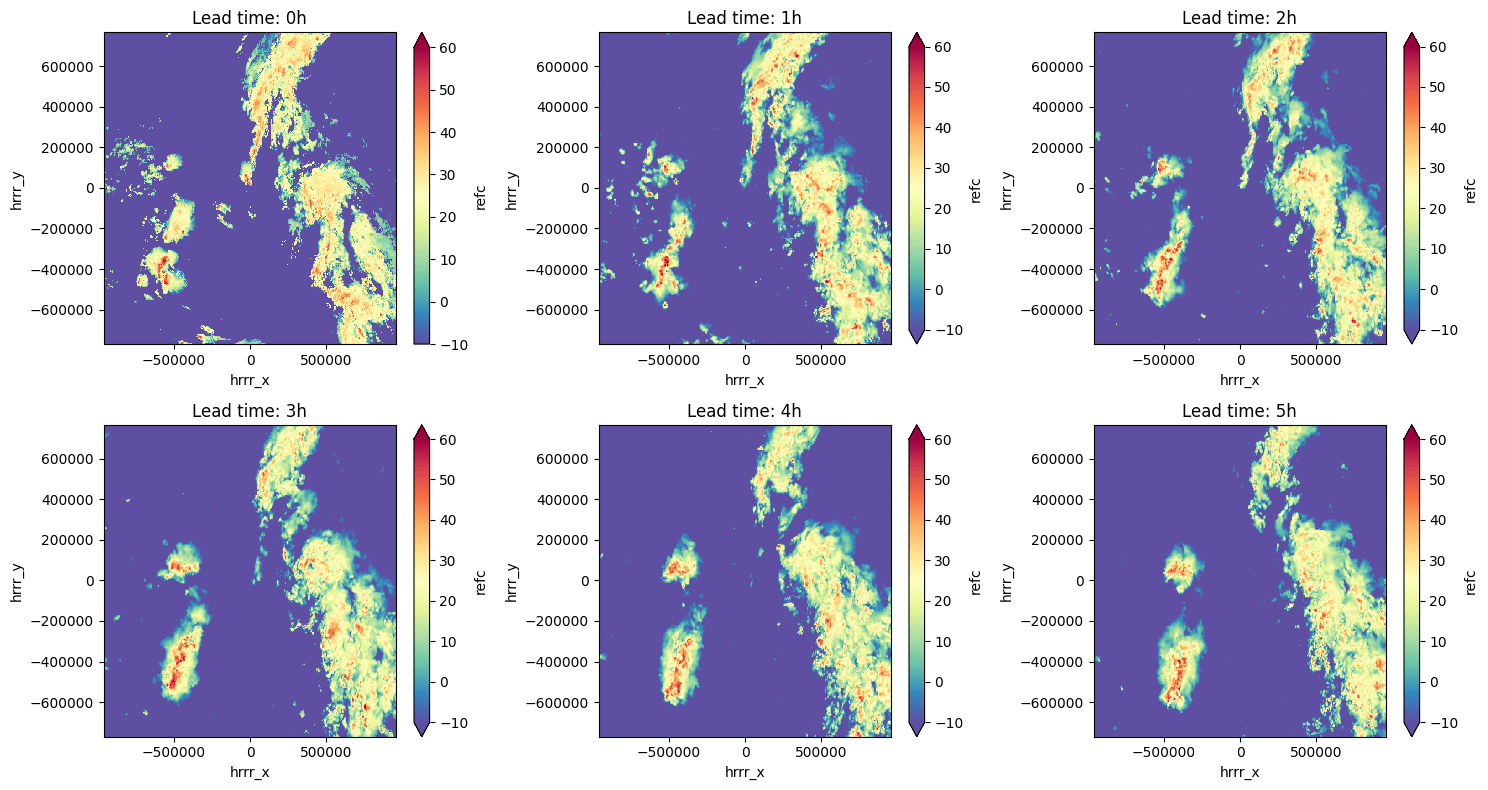

In [23]:
import xarray as xr
import matplotlib.pyplot as plt

ds = xr.open_zarr("stormcast_output.zarr")

# Plot composite radar reflectivity. Need to select the single start time, which
# really means "forecasgt cycle" here.
refc = ds["refc"].isel(time=0)

# plot 5 foreast lead times + initial condition
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, ax in enumerate(axes.flat):
    refc.isel(lead_time=i).plot(ax=ax, cmap="Spectral_r", vmin=-10, vmax=60)
    ax.set_title(f"Lead time: {i}h")
plt.tight_layout()
plt.savefig("stormcast_forecast.png", dpi=150)
plt.show()

# 6. Build my own input dataset
Instead of using `HRRR()` dataset to intialize, and `GFS` for lateral boundary, one can build your own data structure as input for StormCast as shown below. Note that this data class is only for the initial condition. For replacing the GFS lateral boundary conditions when predicting beyond 2 hours, need to do some further as shown in Section 7.

To avoid "Shape Mismatch" or "Variable Missing" errors, ensure your custom data meets these three conditions:

- Variable Names: Use the `model.input_coords["variable"]` list you found earlier to name the coordinates in your xarray.DataArray.

- Grid Projection: StormCast expects data on the HRRR Lambert Conformal grid. If your [ny, nx] dimensions don't match the model's expected grid (usually 1059 x 1799 or a specific regional crop), the model will fail.

- The Conditioning Data: Remember that StormCast is a conditional model. Even if you provide the Initial Condition via data, the model instantiation StormCast.load_model(..., conditioning_data_source=GFS_FX()) still points to a remote source for the "future" forcing. If you want to replace that too, you must pass a second custom data source into the conditioning_data_source argument of the model loader.

In [2]:
import torch
import xarray as xr
import numpy as np
from datetime import datetime
import earth2studio.run as run
from earth2studio.models.px import StormCast
from earth2studio.data import HRRR, GFS_FX
from earth2studio.io import ZarrBackend
from datetime import datetime

class MyLocalData:
    def __init__(self, my_array, variables, lats, lons):
        """
        my_array: Shape [batch, time, lat, lon, channel] or [nb, nt, ny, nx, nc]
        variables: List of strings (e.g., ['t2m', 'u10', ...]) matching model inputs
        """
        self.data = my_array
        self.variables = variables
        self.lats = lats
        self.lons = lons

    def __call__(self, time: datetime, variable: list[str] | str):
        # Convert requested variable to a list if it's a single string
        if isinstance(variable, str):
            variable = [variable]

        # Here we assume 'time' in your array corresponds to the 'time' argument.
        # We wrap your array into an xarray.DataArray which Earth2Studio requires.
        # nb=0 (batch), nt=0 (current time step)
        raw_data = self.data[0, 0, ...] # Selecting first batch/time for the IC
        da = xr.DataArray(
            raw_data[np.newaxis, ...],
            dims=["time","hrrr_y", "hrrr_x", "variable"],
            coords={
                "hrrr_y": self.lats,
                "hrrr_x": self.lons,
                "variable": self.variables,
                "time": time,
            }
        )

        # add time dimension
        #da = da.assign_coords(time=time)

        # Reorder to (variable, lat, lon) as expected by most Earth2Studio models
        return da.sel(variable=variable).transpose("time","variable", "hrrr_y", "hrrr_x")

# Load pretrained model (downloads weights from HuggingFace automatically)
package = StormCast.load_default_package()
model = StormCast.load_model(package, conditioning_data_source=GFS_FX())

# initialize some input dimension parameters
nx = 640
ny = 512
list_of_vars = ['v20hl', 'q1hl', 'u3hl', 't2m', 'u20hl', 'v25hl', 'v5hl', 'Z2hl',
                'v9hl', 'p6hl', 'Z3hl', 'u10m', 't1hl', 't9hl', 'p4hl', 'Z5hl',
                'u10hl', 'v10m', 'q7hl', 'Z20hl', 'u6hl', 'Z6hl', 'q20hl', 'v10hl',
                't4hl', 'Z4hl', 'q30hl', 'p15hl', 'p2hl', 'q15hl', 'p7hl', 'Z25hl',
                'p3hl', 'p20hl', 't7hl', 't30hl', 'u1hl', 't2hl', 't11hl', 'p1hl',
                'q4hl', 't15hl', 'v2hl', 'p11hl', 'p8hl', 'v11hl', 'Z10hl', 'Z30hl',
                't3hl', 'v1hl', 'Z9hl', 'q11hl', 'Z11hl', 't20hl', 'p5hl', 'q8hl',
                'q5hl', 'u4hl', 't13hl', 'p9hl', 'q25hl', 'Z13hl', 'p13hl', 'v30hl',
                'q9hl', 'v4hl', 'mslp', 'q3hl', 'q13hl', 'Z15hl', 't10hl', 'refc',
                'Z7hl', 'Z1hl', 'p10hl', 'u8hl', 'u25hl', 'v8hl', 'u15hl', 'v15hl',
                'u2hl', 'q2hl', 'u11hl', 't5hl', 'v3hl', 'Z8hl', 't8hl', 't25hl',
                'u7hl', 'u5hl', 'u30hl', 'u9hl', 'v6hl', 'q10hl', 'v13hl', 'u13hl',
                'q6hl', 't6hl', 'v7hl']

# define my own input data of shape [nb,ht,nc,ny,nx]
my_array = np.random.rand(1,1,ny,nx,len(list_of_vars))
my_data = MyLocalData(my_array, list_of_vars, np.arange(0,ny), np.arange(0,nx))
starting_time = datetime(year=2024, month=6, day=1, hour=0)
input_data = my_data([starting_time], list_of_vars)
print("Input Data Dimensions:", input_data.dims)
print("Input Data Shape:", input_data.shape)

# Run the forecast. The model will now call my_data instead of GFS/HRRR
io = ZarrBackend("stormcast_output_new.zarr", backend_kwargs={"overwrite": True})
io = run.deterministic(time=[starting_time], nsteps=2, prognostic=model, data=my_data,io=io)

Warp DeprecationWarning: The symbol `warp.context.Device` will soon be removed from the public API. Use `warp.Device` instead.


Input Data Dimensions: ('time', 'variable', 'hrrr_y', 'hrrr_x')
Input Data Shape: (1, 99, 512, 640)
2026-05-03 04:44:09.334 | INFO     | earth2studio.run:deterministic:78 - Running simple workflow!
2026-05-03 04:44:09.335 | INFO     | earth2studio.run:deterministic:85 - Inference device: cuda
2026-05-03 04:44:10.325 | SUCCESS  | earth2studio.run:deterministic:109 - Fetched data from MyLocalData
2026-05-03 04:44:10.689 | INFO     | earth2studio.run:deterministic:139 - Inference starting!



Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

2026-05-03 04:44:12.952 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240601/00/atmos/gfs.t00z.pgrb2.0p25.f000 268990514-579343
2026-05-03 04:44:13.052 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240601/00/atmos/gfs.t00z.pgrb2.0p25.f000 400374183-1259707
2026-05-03 04:44:13.098 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240601/00/atmos/gfs.t00z.pgrb2.0p25.f000 430855049-1235767
2026-05-03 04:44:13.135 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240601/00/atmos/gfs.t00z.pgrb2.0p25.f000 215164860-619908




Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]


...

2026-05-03 04:45:13.000 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240601/00/atmos/gfs.t00z.pgrb2.0p25.f001 410593995-1012216
2026-05-03 04:45:13.039 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240601/00/atmos/gfs.t00z.pgrb2.0p25.f001 266541949-1338219
2026-05-03 04:45:13.083 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240601/00/atmos/gfs.t00z.pgrb2.0p25.f001 342239645-922452
2026-05-03 04:45:13.122 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240601/00/atmos/gfs.t00z.pgrb2.0p25.f001 427289381-979641
2026-05-03 04:45:13.163 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240601/00/atmos/gfs.t00z.pgrb2.0p25.f001 211849597-1211999



Fetching GFS data:   0%|          | 0/26 [00:01<?, ?it/s]

Fetching GFS data: 100%|██████████| 26/26 [00:01<00:00, 22.41it/s]


2026-05-03 04:45:13.205 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240601/00/atmos/gfs.t00z.pgrb2.0p25.f001 428269022-958273
2026-05-03 04:45:13.243 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240601/00/atmos/gfs.t00z.pgrb2.0p25.f001 263779209-720128



Running inference: 100%|██████████| 3/3 [02:03<00:00, 41.19s/it]

2026-05-03 04:46:14.259 | SUCCESS  | earth2studio.run:deterministic:151 - 
Inference complete


In [3]:
# Turn off GFS_FX() update now for truly Nowcasting model
model = StormCast.load_model(package, conditioning_data_source=my_data)
io = ZarrBackend("stormcast_output_new.zarr", backend_kwargs={"overwrite": True})
io = run.deterministic(time=[starting_time], nsteps=2, prognostic=model, data=my_data,io=io)

# Instead of GFS_FX(), use your own data object
# This forces the model to use your local data as the boundary
#model = StormCast.load_model(package, conditioning_data_source=my_data)

2026-05-03 04:46:25.455 | INFO     | earth2studio.run:deterministic:78 - Running simple workflow!
2026-05-03 04:46:25.455 | INFO     | earth2studio.run:deterministic:85 - Inference device: cuda
2026-05-03 04:46:26.379 | SUCCESS  | earth2studio.run:deterministic:109 - Fetched data from MyLocalData
2026-05-03 04:46:26.687 | INFO     | earth2studio.run:deterministic:139 - Inference starting!



Running inference:  33%|███▎      | 1/3 [00:02<00:04,  2.03s/it]


KeyError: "not all values found in index 'variable'"